# CVAE Analysis notebook

This notebook orchestrates analysis using the refactored package `vae_timbre_spaces`.
- Loads a trained checkpoint
- Extracts embeddings (μ, logvar)
- Runs PCA + UMAP visualizations
- Computes silhouette scores
- Performs latent interpolation and saves audio

All outputs are saved under `outputs/`.

In [1]:
# Imports
import sys
from pathlib import Path
import glob
import json
import time

import numpy as np
import pandas as pd
import torch
from torch.utils.data import DataLoader
from sklearn.decomposition import PCA
import plotly.express as px
import plotly.graph_objects as go

PROJECT_ROOT = Path().resolve().parent
SRC_ROOT = PROJECT_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

# package imports (do NOT redefine models/dataset)
from vae_timbre_spaces.models import ConditionalVAE
from vae_timbre_spaces.dataset import NsynthMelCacheDataset, load_examples_json
from vae_timbre_spaces.analysis.embeddings import extract_mu_logvar, save_embeddings
from vae_timbre_spaces.analysis.umap import fit_umap, transform_umap, save_umap_reducer, load_umap_reducer
from vae_timbre_spaces.analysis.silhouette import silhouette_by_family, run_silhouette_for_pitch_window
from vae_timbre_spaces.analysis.interpolation import interpolate_between_mus, decode_from_z
from vae_timbre_spaces.analysis.reconstruction import (
    load_model_from_checkpoint,
    reconstruct_one,
    plot_mel_reconstruction,
    select_interpolation_pair,
    interpolate_and_decode,
    save_interpolation_audio,
    list_interpolation_files,
    norm_to_logmel_db,
    FAMILY_ID_TO_NAME,
    FAMILY_NAME_TO_ID,
    family_to_id,
)

print('Imports OK')

/home/satan/miniconda3/envs/timbre_space_dl/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Imports OK


In [2]:
from datetime import datetime
from pathlib import Path

# Cria um id único por execução
RUN_ID = datetime.now().strftime("%Y%m%d_%H%M%S")

# Ex: outputs/runs/20260218_153012/audio
RUNS_DIR = Path("outputs") / "runs"
AUDIO_RUN_DIR = RUNS_DIR / RUN_ID / "audio"
AUDIO_RUN_DIR.mkdir(parents=True, exist_ok=True)

PLOTS_RUN_DIR = RUNS_DIR / RUN_ID / "plots"
EMB_RUN_DIR   = RUNS_DIR / RUN_ID / "embeddings"
PLOTS_RUN_DIR.mkdir(parents=True, exist_ok=True)
EMB_RUN_DIR.mkdir(parents=True, exist_ok=True)


print("Run folder:", AUDIO_RUN_DIR)
print("Run folder:", PLOTS_RUN_DIR)
print("Run folder:", EMB_RUN_DIR)


Run folder: outputs/runs/20260302_125128/audio
Run folder: outputs/runs/20260302_125128/plots
Run folder: outputs/runs/20260302_125128/embeddings


In [3]:
# # Paths & device
# PROJECT_ROOT = Path().resolve().parent
CKPT_DIR = PROJECT_ROOT / 'notebooks' / 'ckpts'
# OUT_DIR = PROJECT_ROOT / 'outputs'
# PLOTS_DIR = OUT_DIR / 'plots'
# AUDIO_DIR = OUT_DIR / 'audio'

# for p in (OUT_DIR, PLOTS_DIR, AUDIO_DIR):
#     p.mkdir(parents=True, exist_ok=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)

device: cuda


In [4]:
# 1) Locate checkpoint (pick latest if multiple)
ckpt_paths = sorted(CKPT_DIR.glob('*.pt'), key=lambda p: p.stat().st_mtime)
if len(ckpt_paths) == 0:
    raise FileNotFoundError(f'No checkpoints found in {CKPT_DIR}')

CKPT_PATH = ckpt_paths[-1]
print('Using checkpoint:', CKPT_PATH)

ckpt = torch.load(CKPT_PATH, map_location=device)
config = ckpt.get('config', {})
print('Checkpoint config keys:', list(config.keys()))

Using checkpoint: /home/satan/git/VAE-Timbre-Spaces/notebooks/ckpts/cvae_pitch_lat64_beta1.0_fb0.25_20260218_181117_epoch15.pt
Checkpoint config keys: ['LATENT_DIM', 'BETA_MAX', 'FREE_BITS', 'WARMUP_STEPS', 'LR', 'cond_dim', 'pitch_vocab', 'N_MELS', 'N_FFT', 'HOP', 'T', 'SR']


/tmp/ipykernel_44082/3172288365.py:9: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(CKPT_PATH, map_location=device)


In [5]:
print(type(ckpt))
print(ckpt.keys() if isinstance(ckpt, dict) else "Not a dict")

print(type(ckpt['model_state']))
print(list(ckpt['model_state'].keys())[:5])

print(CKPT_PATH)

<class 'dict'>
dict_keys(['model_state', 'optimizer_state', 'global_step', 'epoch', 'config'])
<class 'collections.OrderedDict'>
['encoder.conv1.weight', 'encoder.conv1.bias', 'encoder.conv2.weight', 'encoder.conv2.bias', 'encoder.conv3.weight']
/home/satan/git/VAE-Timbre-Spaces/notebooks/ckpts/cvae_pitch_lat64_beta1.0_fb0.25_20260218_181117_epoch15.pt


In [6]:
ckpt = torch.load(CKPT_PATH, map_location=device)

print("Keys:", ckpt.keys())
print("model_state length:", len(ckpt["model_state"]))


Keys: dict_keys(['model_state', 'optimizer_state', 'global_step', 'epoch', 'config'])
model_state length: 19


/tmp/ipykernel_44082/3558755710.py:1: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(CKPT_PATH, map_location=device)


In [7]:
# 2) Instantiate model from checkpoint config
ckpt = torch.load(CKPT_PATH, map_location=device)

# Detect format automatically
if isinstance(ckpt, dict) and "model_state" in ckpt:
    state_dict = ckpt["model_state"]
    config = ckpt.get("config", {})
else:
    state_dict = ckpt
    config = {}

cvae = ConditionalVAE(
    latent_dim=int(config.get("LATENT_DIM", 32)),
    pitch_vocab=int(config.get("pitch_vocab", 128)),
    cond_dim=int(config.get("cond_dim", 16)),
).to(device)

cvae.load_state_dict(state_dict)
cvae.eval()

print("Model loaded from:", CKPT_PATH)


/tmp/ipykernel_44082/1946768830.py:2: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(CKPT_PATH, map_location=device)


Model loaded from: /home/satan/git/VAE-Timbre-Spaces/notebooks/ckpts/cvae_pitch_lat64_beta1.0_fb0.25_20260218_181117_epoch15.pt


In [8]:
# 3) Prepare test dataloader
SPLIT = 'test'  # change to 'valid' if desired
split_root = PROJECT_ROOT / 'data' / f'nsynth-{SPLIT}.jsonwav' / f'nsynth-{SPLIT}'
# fallback if original layout different
if not split_root.exists():
    # try the notebook's TRAIN/VALID/TEST_ROOT variables path
    split_root = PROJECT_ROOT / 'data' / f'nsynth-{SPLIT}'

print('split_root:', split_root)
keys, examples = load_examples_json(split_root)
print('num examples:', len(keys))

cache_dir = PROJECT_ROOT / 'data' / 'nsynth_mel_cache' / SPLIT
print('cache_dir:', cache_dir)

dataset = NsynthMelCacheDataset(keys, examples, cache_dir)
loader = DataLoader(dataset, batch_size=128, shuffle=False, num_workers=4, pin_memory=(device.type=='cuda'))

split_root: /home/satan/git/VAE-Timbre-Spaces/data/nsynth-test.jsonwav/nsynth-test
num examples: 4096
cache_dir: /home/satan/git/VAE-Timbre-Spaces/data/nsynth_mel_cache/test


In [9]:
# 4) Extract embeddings (mu, logvar, pitch, family, keys)
N_SAMPLES = min(20000, len(keys))
mu_all, logvar_all, pitch_all, family_all, keys_all = extract_mu_logvar(cvae, loader, n_samples=N_SAMPLES, device=device)
print('mu_all shape:', mu_all.shape)

# Save embeddings
model_name = CKPT_PATH.stem
print(EMB_RUN_DIR)
emb_path = save_embeddings(mu_all, logvar_all, pitch_all, family_all, keys_all, split=SPLIT, model_name=model_name, out_dir=EMB_RUN_DIR)
print('Saved embeddings to:', emb_path)

mu_all shape: (4096, 64)
outputs/runs/20260302_125128/embeddings
Saved embeddings to: outputs/runs/20260302_125128/embeddings/embeddings_test_cvae_pitch_lat64_beta1.0_fb0.25_20260218_181117_epoch15.npz


In [10]:
FAMILY_ID_TO_NAME = {
    0: "bass",
    1: "brass",
    2: "flute",
    3: "guitar",
    4: "keyboard",
    5: "mallet",
    6: "organ",
    7: "reed",
    8: "string",
    9: "synth_lead",
    10: "vocal",
}

def family_to_name(fid: int) -> str:
    return FAMILY_ID_TO_NAME.get(int(fid), f"family_{int(fid)}")


In [11]:
pca = PCA(n_components=2, random_state=42)
mu_pca = pca.fit_transform(mu_all)

df_pca = pd.DataFrame({
    "pc1": mu_pca[:, 0],
    "pc2": mu_pca[:, 1],
    "pitch": pitch_all.astype(int),
    "family": family_all.astype(int),
    "family_name": [family_to_name(f) for f in family_all],
    "key": keys_all,
})

fig = px.scatter(
    df_pca,
    x="pc1", y="pc2",
    color="family_name",
    hover_data=["family", "pitch", "key"],
    title=f"PCA (mu) — {model_name} — {SPLIT}",
)

img_path = PLOTS_RUN_DIR / f"pca_{model_name}_{SPLIT}.png"
html_fallback = PLOTS_RUN_DIR / f"pca_{model_name}_{SPLIT}.html"
try:
    fig.write_image(str(img_path))
    print("Saved PCA plot (png):", img_path)
except Exception:
    print(f"Warning: Failed to save PCA plot as image. Attempting to save interactive HTML instead at {html_fallback}")
    try:
        fig.write_html(str(html_fallback))
        print("Saved PCA plot (html):", html_fallback)
    except Exception:
        print("Could not save PCA plot (image or html export failed).")

fig.show()


Saved PCA plot (png): outputs/runs/20260302_125128/plots/pca_cvae_pitch_lat64_beta1.0_fb0.25_20260218_181117_epoch15_test.png


In [12]:
# 6) UMAP visualization
reducer, mu_umap = fit_umap(mu_all, n_neighbors=30, min_dist=0.1, random_state=42)

df_umap = pd.DataFrame({
    "u1": mu_umap[:, 0],
    "u2": mu_umap[:, 1],
    "pitch": pitch_all.astype(int),
    "family": family_all.astype(int),
    "family_name": [family_to_name(f) for f in family_all],
    "key": keys_all,
})

fig = px.scatter(
    df_umap,
    x="u1", y="u2",
    color="family_name",
    hover_data=["family", "pitch", "key"],
    title=f"UMAP (mu) — {model_name} — {SPLIT}",
)

img_path = PLOTS_RUN_DIR / f"umap_{model_name}_{SPLIT}.png"
html_fallback = PLOTS_RUN_DIR / f"umap_{model_name}_{SPLIT}.html"
try:
    fig.write_image(str(img_path))
    print("Saved UMAP plot (png):", img_path)
except Exception:
    print(f"Warning: Failed to save UMAP plot as image. Attempting to save interactive HTML instead at {html_fallback}")
    try:
        fig.write_html(str(html_fallback))
        print("Saved UMAP plot (html):", html_fallback)
    except Exception:
        print("Could not save UMAP plot (image or html export failed).")

fig.show()


/home/satan/miniconda3/envs/timbre_space_dl/lib/python3.10/site-packages/umap/umap_.py:1952: UserWarning:

n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.



Saved UMAP plot (png): outputs/runs/20260302_125128/plots/umap_cvae_pitch_lat64_beta1.0_fb0.25_20260218_181117_epoch15_test.png


In [13]:
# 7) Silhouette: global per family
sil_global_df = silhouette_by_family(mu_all, family_all)
csv_path = PLOTS_RUN_DIR / f'silhouette_global_{model_name}_{SPLIT}.csv'
sil_global_df.to_csv(csv_path)
print('Silhouette by family:\n', sil_global_df)
print('Saved silhouette table:', csv_path)

# quick bar plot
fig = px.bar(sil_global_df.reset_index(), x='family', y='mean_silhouette', error_y='std_silhouette', title=f'Silhouette by family — {model_name} — {SPLIT}')

img_path = PLOTS_RUN_DIR / f'silhouette_global_{model_name}_{SPLIT}.png'
html_fallback = PLOTS_RUN_DIR / f'silhouette_global_{model_name}_{SPLIT}.html'
try:
    fig.write_image(str(img_path))
    print('Saved silhouette plot (png):', img_path)
except Exception:
    print(f"Warning: Failed to save silhouette plot as image. Attempting to save interactive HTML instead at {html_fallback}")
    try:
        fig.write_html(str(html_fallback))
        print('Saved silhouette plot (html):', html_fallback)
    except Exception:
        print('Could not save silhouette plot (image or html export failed).')

fig.show()

Silhouette by family:
         mean_silhouette  std_silhouette  n_samples
family                                            
5              0.575929        0.155583        202
10             0.101421        0.111906        141
1             -0.118194        0.112888        269
2             -0.312698        0.299060        180
6             -0.468279        0.287274        502
7             -0.490155        0.209842        235
3             -0.560442        0.229502        652
4             -0.603390        0.224538        766
0             -0.641276        0.119833        843
8             -0.753487        0.135322        306
Saved silhouette table: outputs/runs/20260302_125128/plots/silhouette_global_cvae_pitch_lat64_beta1.0_fb0.25_20260218_181117_epoch15_test.csv
Saved silhouette plot (png): outputs/runs/20260302_125128/plots/silhouette_global_cvae_pitch_lat64_beta1.0_fb0.25_20260218_181117_epoch15_test.png
Saved silhouette plot (png): outputs/runs/20260302_125128/plots/silhouette_g

In [14]:
# Pitch-window silhouette example: pitch 60 ± 1
pitch_center = 60
sil_pitch_df = run_silhouette_for_pitch_window(mu_all, pitch_all, family_all, pitch_center=pitch_center, tolerance=1, min_samples_per_family=10)
path_csv = PLOTS_RUN_DIR / f'silhouette_pitch{pitch_center}_{model_name}_{SPLIT}.csv'
sil_pitch_df.to_csv(path_csv)
print(f'Silhouette for pitch {pitch_center}±1:\n', sil_pitch_df)
print('Saved pitch-window silhouette:', path_csv)

fig = px.bar(sil_pitch_df.reset_index(), x='family', y='mean_silhouette', error_y='std_silhouette', title=f'Silhouette by family (pitch {pitch_center}±1) — {model_name} — {SPLIT}')

img_path = PLOTS_RUN_DIR / f'silhouette_pitch{pitch_center}_{model_name}_{SPLIT}.png'
html_fallback = PLOTS_RUN_DIR / f'silhouette_pitch{pitch_center}_{model_name}_{SPLIT}.html'
try:
    fig.write_image(str(img_path))
    print('Saved silhouette pitch plot (png):', img_path)
except Exception:
    try:
        fig.write_html(str(html_fallback))
        print('Saved silhouette pitch plot (html):', html_fallback)
    except Exception:
        print('Could not save silhouette pitch plot (image or html export failed).')

fig.show()

Silhouette for pitch 60±1:
         mean_silhouette  std_silhouette  n_samples
family                                            
3              0.418193        0.214666         25
7              0.054921        0.273921         14
0             -0.121935        0.341638         34
1             -0.212351        0.186811         20
8             -0.493924        0.180564         18
6             -0.514569        0.179870         24
4             -0.543265        0.084537         29
Saved pitch-window silhouette: outputs/runs/20260302_125128/plots/silhouette_pitch60_cvae_pitch_lat64_beta1.0_fb0.25_20260218_181117_epoch15_test.csv
Saved silhouette pitch plot (png): outputs/runs/20260302_125128/plots/silhouette_pitch60_cvae_pitch_lat64_beta1.0_fb0.25_20260218_181117_epoch15_test.png
Saved silhouette pitch plot (png): outputs/runs/20260302_125128/plots/silhouette_pitch60_cvae_pitch_lat64_beta1.0_fb0.25_20260218_181117_epoch15_test.png


In [15]:
# 8) Interpolation: pick two samples by family name (string) and generate audio
from vae_timbre_spaces.analysis.reconstruction import (
    select_interpolation_pair,
    interpolate_and_decode,
    save_interpolation_audio,
    list_interpolation_files,
)

# Choose families and options (edit if desired)
SRC_FAMILY = "mallet"
DST_FAMILY = "vocal"
USE_PITCH_FILTER = True
PITCH_TARGET = 60
PITCH_TOL = 1
SRC_KEY_CONTAINS = None
DST_KEY_CONTAINS = None
PICK_MODE = "random"
SEED = 42
n_steps = 9

# select pair
idx_a, idx_b, pitch_interp = select_interpolation_pair(
    family_all, pitch_all, keys_all,
    src_family=SRC_FAMILY, dst_family=DST_FAMILY,
    use_pitch_filter=USE_PITCH_FILTER, pitch_target=PITCH_TARGET, pitch_tol=PITCH_TOL,
    src_key_contains=SRC_KEY_CONTAINS, dst_key_contains=DST_KEY_CONTAINS,
    pick_mode=PICK_MODE, seed=SEED,
)

print('[selected A]', 'family:', SRC_FAMILY, f"(id={family_to_id(SRC_FAMILY)})", '| pitch:', int(pitch_all[idx_a]), '| key:', keys_all[idx_a])
print('[selected B]', 'family:', DST_FAMILY, f"(id={family_to_id(DST_FAMILY)})", '| pitch:', int(pitch_all[idx_b]), '| key:', keys_all[idx_b])

# interpolate and decode
x_hat, alphas = interpolate_and_decode(cvae, mu_all, idx_a, idx_b, n_steps=n_steps, pitch_interp=pitch_interp, device=device)

# save audio
saved_paths = save_interpolation_audio(x_hat, alphas, AUDIO_RUN_DIR, model_name, SPLIT, SRC_FAMILY, DST_FAMILY, pitch_interp)
for p in saved_paths:
    print('Saved:', p)

# list and display inline
from IPython.display import Audio, display
for p in list_interpolation_files(AUDIO_RUN_DIR, model_name, SPLIT):
    print('---', p.name)
    display(Audio(str(p), rate=16000))

[selected A] family: mallet (id=5) | pitch: 59 | key: mallet_acoustic_062-059-127
[selected B] family: vocal (id=10) | pitch: 59 | key: vocal_acoustic_000-059-100
Saved: outputs/runs/20260302_125128/audio/interp_cvae_pitch_lat64_beta1.0_fb0.25_20260218_181117_epoch15_test_mallet_to_vocal_p59_a0.00_0.wav
Saved: outputs/runs/20260302_125128/audio/interp_cvae_pitch_lat64_beta1.0_fb0.25_20260218_181117_epoch15_test_mallet_to_vocal_p59_a0.12_1.wav
Saved: outputs/runs/20260302_125128/audio/interp_cvae_pitch_lat64_beta1.0_fb0.25_20260218_181117_epoch15_test_mallet_to_vocal_p59_a0.25_2.wav
Saved: outputs/runs/20260302_125128/audio/interp_cvae_pitch_lat64_beta1.0_fb0.25_20260218_181117_epoch15_test_mallet_to_vocal_p59_a0.38_3.wav
Saved: outputs/runs/20260302_125128/audio/interp_cvae_pitch_lat64_beta1.0_fb0.25_20260218_181117_epoch15_test_mallet_to_vocal_p59_a0.50_4.wav
Saved: outputs/runs/20260302_125128/audio/interp_cvae_pitch_lat64_beta1.0_fb0.25_20260218_181117_epoch15_test_mallet_to_vocal_p

--- interp_cvae_pitch_lat64_beta1.0_fb0.25_20260218_181117_epoch15_test_mallet_to_vocal_p59_a0.12_1.wav


--- interp_cvae_pitch_lat64_beta1.0_fb0.25_20260218_181117_epoch15_test_mallet_to_vocal_p59_a0.25_2.wav


--- interp_cvae_pitch_lat64_beta1.0_fb0.25_20260218_181117_epoch15_test_mallet_to_vocal_p59_a0.38_3.wav


--- interp_cvae_pitch_lat64_beta1.0_fb0.25_20260218_181117_epoch15_test_mallet_to_vocal_p59_a0.50_4.wav


--- interp_cvae_pitch_lat64_beta1.0_fb0.25_20260218_181117_epoch15_test_mallet_to_vocal_p59_a0.62_5.wav


--- interp_cvae_pitch_lat64_beta1.0_fb0.25_20260218_181117_epoch15_test_mallet_to_vocal_p59_a0.75_6.wav


--- interp_cvae_pitch_lat64_beta1.0_fb0.25_20260218_181117_epoch15_test_mallet_to_vocal_p59_a0.88_7.wav


--- interp_cvae_pitch_lat64_beta1.0_fb0.25_20260218_181117_epoch15_test_mallet_to_vocal_p59_a1.00_8.wav


Reconstructing key: vocal_synthetic_003-062-050 pitch: 62


/home/satan/git/VAE-Timbre-Spaces/src/vae_timbre_spaces/analysis/reconstruction.py:209: FutureWarning:

You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.



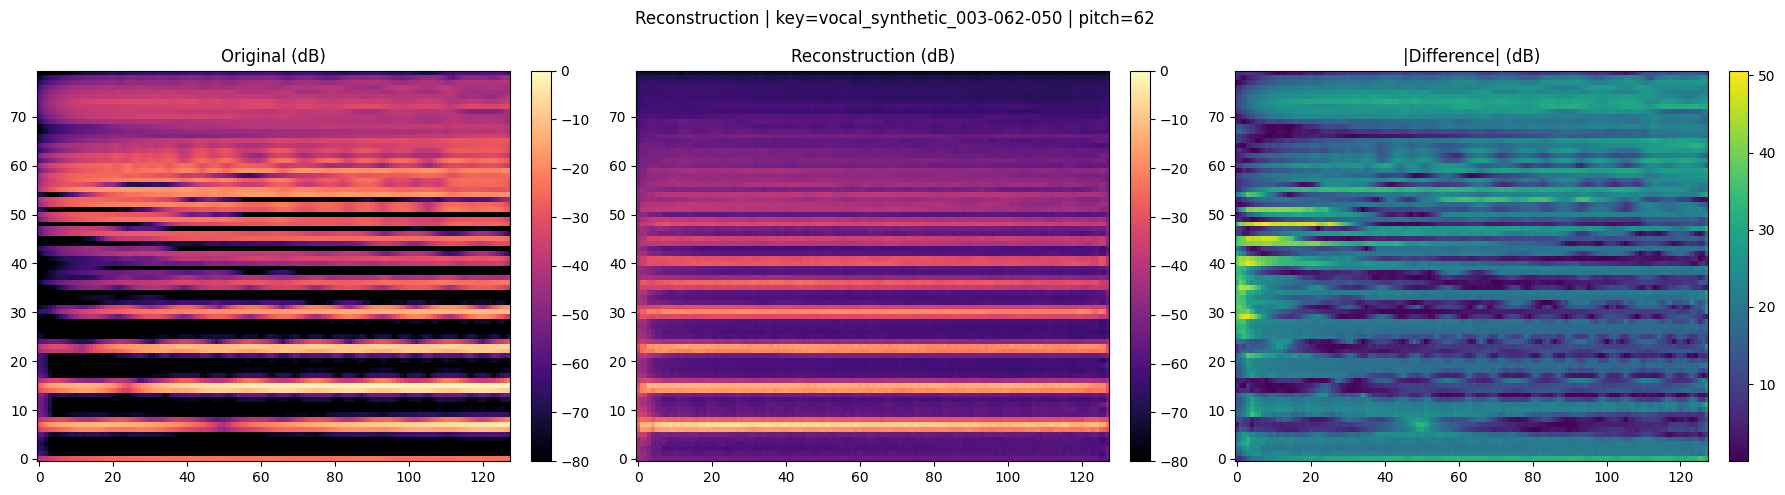

In [16]:
# Options: select by key substring or use first batch
# Set INSTR_KEY to a substring of the NSynth key you want to reconstruct, e.g.:
# INSTR_KEY = "bass_electronic_018-023"
# or leave as None to use the first sample from the loader
INSTR_KEY = "vocal_synthetic_003-062-050"

# Load model (reuse CKPT_PATH from earlier cell)
model_for_recon = load_model_from_checkpoint(CKPT_PATH, device=device)

if INSTR_KEY is None:
    # Pick one sample from dataset (first batch)
    x_batch, pitch_batch, family_batch, key_batch = next(iter(loader))

    x_input = x_batch[0, 0]  # (80, T) normalized
    pitch_input = int(pitch_batch[0].item())
    key_input = key_batch[0]
else:
    # find a matching key from the extracted keys_all
    matches = [i for i, k in enumerate(keys_all) if INSTR_KEY in str(k)]
    if len(matches) == 0:
        raise RuntimeError(f"No keys matching '{INSTR_KEY}' found in embeddings keys.")
    idx = matches[0]
    key_input = keys_all[idx]

    # load cached mel from cache_dir (expects path ../data/nsynth_mel_cache/<split>/<key>.pt)
    pt_path = Path(cache_dir) / f"{key_input}.pt"
    if not pt_path.exists():
        # try with string conversion
        pt_path = Path(cache_dir) / f"{str(key_input)}.pt"
    if not pt_path.exists():
        raise FileNotFoundError(f"Cache file not found: {pt_path}")

    x_tensor = torch.load(pt_path, weights_only=True)
    # x_tensor shape: (1, 80, T) -> pick first channel
    x_input = x_tensor[0]

    # get pitch either from examples dict or from pitch_all
    try:
        pitch_input = int(examples[str(key_input)]['pitch'])
    except Exception:
        pitch_input = int(pitch_all[idx])

print('Reconstructing key:', key_input, 'pitch:', pitch_input)

# Reconstruct
xhat_norm = reconstruct_one(model_for_recon, x_input, pitch_input)

# Plot
plot_mel_reconstruction(x_input, xhat_norm, title=f"Reconstruction | key={key_input} | pitch={pitch_input}")


In [17]:
import numpy as _np
#  UMAP reducer path
UMAP_REDUCER_PATH = Path('outputs') / 'analysis' / f'umap_reducer_{SPLIT}_{model_name}.pkl'
EMB2D_PATH = Path('outputs') / 'analysis' / f'emb2d_{SPLIT}_{model_name}.npz'

# Load or fit reducer
from vae_timbre_spaces.analysis.umap import save_umap_reducer, load_umap_reducer
from vae_timbre_spaces.analysis.interpolation import (
    interpolate_latents,
    select_pair_by_label,
    project_trajectory_umap,
    plot_umap_with_trajectory,
)

if UMAP_REDUCER_PATH.exists():
    reducer = load_umap_reducer(UMAP_REDUCER_PATH)
    emb2d = reducer.transform(mu_all)
else:
    reducer, emb2d = fit_umap(mu_all, n_neighbors=30, min_dist=0.1, random_state=42)
    save_umap_reducer(reducer, UMAP_REDUCER_PATH)
    _np.savez_compressed(EMB2D_PATH, emb2d=emb2d)

# select pair by label names (family_name array)
labels = [family_to_name(f) for f in family_all]
src_label = 'mallet'
dst_label = 'vocal'
idx_a, idx_b = select_pair_by_label(np.array(labels), src_label, dst_label, seed=42)

muA = mu_all[idx_a]
muB = mu_all[idx_b]

traj_mu, alphas = interpolate_latents(muA, muB, n_steps=9)
traj2d = project_trajectory_umap(reducer, traj_mu)

# plot and save
plot_path = PLOTS_RUN_DIR / f'umap_traj_{model_name}_{SPLIT}.png'
fig = plot_umap_with_trajectory(emb2d, np.array(labels), traj2d, title=f'UMAP + trajectory {src_label}->{dst_label}', save_path=plot_path)
print('Saved trajectory plot:', plot_path)

# reversed direction
idx_a_rev, idx_b_rev = select_pair_by_label(np.array(labels), dst_label, src_label, seed=43)
muA_rev = mu_all[idx_a_rev]
muB_rev = mu_all[idx_b_rev]
traj_mu_rev, alphas_rev = interpolate_latents(muA_rev, muB_rev, n_steps=9)
traj2d_rev = project_trajectory_umap(reducer, traj_mu_rev)
plot_path_rev = PLOTS_RUN_DIR / f'umap_traj_{model_name}_{SPLIT}.png'
fig2 = plot_umap_with_trajectory(emb2d, np.array(labels), traj2d_rev, title=f'UMAP + trajectory {dst_label}->{src_label}', save_path=plot_path_rev)
print('Saved reversed trajectory plot:', plot_path_rev)

Saved trajectory plot: outputs/runs/20260302_125128/plots/umap_traj_cvae_pitch_lat64_beta1.0_fb0.25_20260218_181117_epoch15_test.png
Saved reversed trajectory plot: outputs/runs/20260302_125128/plots/umap_traj_cvae_pitch_lat64_beta1.0_fb0.25_20260218_181117_epoch15_test.png
Saved reversed trajectory plot: outputs/runs/20260302_125128/plots/umap_traj_cvae_pitch_lat64_beta1.0_fb0.25_20260218_181117_epoch15_test.png


In [18]:
# PCA projection + trajectory (similar to UMAP cell)
import numpy as _np
from pathlib import Path
from vae_timbre_spaces.analysis.pca import (
    fit_pca,
    transform_pca,
    save_pca_model,
    load_pca_model,
)
from vae_timbre_spaces.analysis.interpolation import (
    interpolate_latents,
    select_pair_by_label,
    plot_pca_with_trajectory,
)

PCA_MODEL_PATH = Path('outputs') / 'analysis' / f'pca_model_{SPLIT}_{model_name}.pkl'
PCA_EMB2D_PATH = Path('outputs') / 'analysis' / f'pca2d_{SPLIT}_{model_name}.npz'

if PCA_MODEL_PATH.exists():
    pca = load_pca_model(PCA_MODEL_PATH)
    emb2d = transform_pca(pca, mu_all)
else:
    pca, emb2d = fit_pca(mu_all, n_components=2, random_state=42)
    save_pca_model(pca, PCA_MODEL_PATH)
    _np.savez_compressed(PCA_EMB2D_PATH, emb2d=emb2d)

# select pair by label names (family_name array)
labels = [family_to_name(f) for f in family_all]
src_label = 'mallet'
dst_label = 'vocal'
idx_a, idx_b = select_pair_by_label(np.array(labels), src_label, dst_label, seed=42)

muA = mu_all[idx_a]
muB = mu_all[idx_b]

traj_mu, alphas = interpolate_latents(muA, muB, n_steps=9)
traj2d = transform_pca(pca, traj_mu)

# plot and save
plot_path = PLOTS_RUN_DIR / f'pca_traj_{model_name}_{SPLIT}_{src_label}_to_{dst_label}.png'
fig = plot_pca_with_trajectory(emb2d, np.array(labels), traj2d, title=f'PCA + trajectory {src_label}->{dst_label}', save_path=plot_path)
print('Saved PCA trajectory plot:', plot_path)

# reversed direction
idx_a_rev, idx_b_rev = select_pair_by_label(np.array(labels), dst_label, src_label, seed=43)
muA_rev = mu_all[idx_a_rev]
muB_rev = mu_all[idx_b_rev]
traj_mu_rev, alphas_rev = interpolate_latents(muA_rev, muB_rev, n_steps=9)
traj2d_rev = transform_pca(pca, traj_mu_rev)
plot_path_rev = PLOTS_RUN_DIR / f'pca_traj_{model_name}_{SPLIT}_{dst_label}_to_{src_label}.png'
fig2 = plot_pca_with_trajectory(emb2d, np.array(labels), traj2d_rev, title=f'PCA + trajectory {dst_label}->{src_label}', save_path=plot_path_rev)
print('Saved PCA reversed trajectory plot:', plot_path_rev)

Saved PCA trajectory plot: outputs/runs/20260302_125128/plots/pca_traj_cvae_pitch_lat64_beta1.0_fb0.25_20260218_181117_epoch15_test_mallet_to_vocal.png
Saved PCA reversed trajectory plot: outputs/runs/20260302_125128/plots/pca_traj_cvae_pitch_lat64_beta1.0_fb0.25_20260218_181117_epoch15_test_vocal_to_mallet.png
Saved PCA reversed trajectory plot: outputs/runs/20260302_125128/plots/pca_traj_cvae_pitch_lat64_beta1.0_fb0.25_20260218_181117_epoch15_test_vocal_to_mallet.png


In [20]:
# 6.5) t-SNE visualization (fit or load cached embeddings)
from vae_timbre_spaces.analysis.tsne import (
    fit_tsne,
    save_tsne_embeddings,
    load_tsne_embeddings,
    plot_tsne,
)

TSNE_EMB2D_PATH = Path('outputs') / 'analysis' / f'tsne2d_{SPLIT}_{model_name}.npz'

labels = [family_to_name(f) for f in family_all]
labels_arr = np.array(labels)

if TSNE_EMB2D_PATH.exists():
    tsne_data = load_tsne_embeddings(TSNE_EMB2D_PATH)
    emb2d = tsne_data['emb2d']
    print('Loaded t-SNE embeddings from:', TSNE_EMB2D_PATH)
else:
    print('Fitting t-SNE (this may take a while)...')
    tsne, emb2d = fit_tsne(mu_all, perplexity=30, random_state=42)
    save_tsne_embeddings(TSNE_EMB2D_PATH, emb2d, {'labels': labels, 'pitch': pitch_all, 'family': family_all, 'keys': keys_all})
    print('Saved t-SNE embeddings to:', TSNE_EMB2D_PATH)

# Full plot
tsne_plot_path = PLOTS_RUN_DIR / f'tsne_{model_name}_{SPLIT}.html'
fig = plot_tsne(emb2d, labels_arr, title=f't-SNE (mu) — {model_name} — {SPLIT}', save_path=tsne_plot_path)
print('Saved t-SNE plot (html):', tsne_plot_path)

# Filtered plot (mallet vs vocal)
filtered_plot_path = PLOTS_RUN_DIR / f'tsne_{model_name}_{SPLIT}_mallet_vocal.html'
fig2 = plot_tsne(emb2d, labels_arr, title=f't-SNE (mu) — {model_name} — {SPLIT} (mallet vs vocal)', save_path=filtered_plot_path, filter_labels=['mallet', 'vocal'])
print('Saved filtered t-SNE plot (html):', filtered_plot_path)


Fitting t-SNE (this may take a while)...
Saved t-SNE embeddings to: outputs/analysis/tsne2d_test_cvae_pitch_lat64_beta1.0_fb0.25_20260218_181117_epoch15.npz
Saved t-SNE embeddings to: outputs/analysis/tsne2d_test_cvae_pitch_lat64_beta1.0_fb0.25_20260218_181117_epoch15.npz


Saved t-SNE plot (html): outputs/runs/20260302_125128/plots/tsne_cvae_pitch_lat64_beta1.0_fb0.25_20260218_181117_epoch15_test.html


Saved filtered t-SNE plot (html): outputs/runs/20260302_125128/plots/tsne_cvae_pitch_lat64_beta1.0_fb0.25_20260218_181117_epoch15_test_mallet_vocal.html
